# Implementation of Generative Forecasting using Joint Probability Models on KS PDE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg
import sys
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim

In [2]:
dataset = np.load("/kaggle/input/datasets/theredatom/ks-1d-pde/ks_dataset_imex.npy")

In [3]:
class JointWindowDataset(Dataset):
    def __init__(self, trajectory, n=2, num_windows=1_000_000):
        self.trajectory = trajectory
        self.n = n
        self.num_windows = min(num_windows, len(trajectory) - n + 1)
        
        mean_per_trajectory = trajectory[:self.num_windows+(n-1)].mean(axis=0).astype(np.float32)
        std_per_trajectory = trajectory[:self.num_windows+(n-1)].std(axis=0).astype(np.float32)
        
        self.mean = np.tile(mean_per_trajectory,self.n)
        self.std = np.tile(std_per_trajectory,self.n) + 1e-8
        

    def __len__(self):
        return self.num_windows

    def __getitem__(self, idx):
        window = self.trajectory[idx:idx+self.n].reshape(-1)
        window = window.astype(np.float32)
        window = (window - self.mean) / self.std
        return torch.from_numpy(window)
        

In [4]:
train_dataset = JointWindowDataset(dataset, n=2, num_windows=1_000_000)

In [5]:
train_dataloader = DataLoader(train_dataset,batch_size=2000,shuffle=True,num_workers=4)

In [6]:
print(f'Number of time windows (samples) in the Training Dataset = {len(train_dataset)}')

Number of time windows (samples) in the Training Dataset = 1000000


In [7]:
class ContinuousNADE(nn.Module):
    def __init__(self,input_dim = 400, hidden_dim = 1500):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.W = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.01)
        self.c = nn.Parameter(torch.zeros(hidden_dim))

        self.V_mu = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.b_mu = nn.Parameter(torch.zeros(input_dim))

        self.V_log_sigma = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.b_log_sigma = nn.Parameter(torch.zeros(input_dim))

    def forward(self,x):
        batch_size = x.shape[0]

        mu_outputs = torch.zeros_like(x)
        log_sigma_outputs = torch.zeros_like(x)

        a_i = self.c.repeat(batch_size,1)

        for i in range(self.input_dim):
            h_i = torch.relu(a_i)
            mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
            log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]
            log_sigma_i = torch.clamp(log_sigma_i, min=-5, max=2)
            mu_outputs[:, i] = mu_i
            log_sigma_outputs[:, i] = log_sigma_i

            if i < self.input_dim - 1:
                v_i = x[:, i].unsqueeze(1)
                W_i = self.W[:, i].unsqueeze(0)
                a_i = a_i + v_i * W_i

        return mu_outputs, log_sigma_outputs

    def sample(self):
        generated_sequence = torch.zeros(self.input_dim)
        a_i = self.c.clone()

        with torch.no_grad():
            for i in range(self.input_dim):
                h_i = torch.relu(a_i)
                mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
                log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]

                sigma_i = torch.exp(log_sigma_i)
                sampled_value = mu_i + sigma_i * torch.randn(1, device=mu_i.device)
                generated_sequence[i] = sampled_value
                if i < self.input_dim - 1:
                    a_i = a_i + self.W[:, i] * sampled_value

        return generated_sequence


    def sample_batch(self,batch_size):
        device=self.c.device

        generated=torch.zeros(batch_size,self.input_dim,device=device)
        a_i=self.c.unsqueeze(0).repeat(batch_size,1)

        with torch.no_grad():
            for i in range(self.input_dim):
                h_i=torch.relu(a_i)

                mu_i=h_i@self.V_mu[i]+self.b_mu[i]
                log_sigma_i=h_i@self.V_log_sigma[i]+self.b_log_sigma[i]
                log_sigma_i=torch.clamp(log_sigma_i,min=-5,max=2)

                sigma_i=torch.exp(log_sigma_i)

                sampled_values=mu_i+sigma_i*torch.randn(batch_size,device=device)

                generated[:,i]=sampled_values

                if i<self.input_dim-1:
                    a_i=a_i+sampled_values.unsqueeze(1)*self.W[:,i].unsqueeze(0)

        return generated

In [8]:
def gaussian_nll_loss(mu, log_sigma, target):
    variance = torch.exp(log_sigma) ** 2
    loss = 0.5 * ((target - mu) ** 2 / variance) + log_sigma + 0.5 * np.log(2 * np.pi)
    #Sum across the 6 dimensions, then get the mean for the batch
    return loss.sum(dim=1).mean()

In [9]:
'''
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = ContinuousNADE()

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model, device_ids=[0, 1])
    
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4) 
train_loss_history = []
epochs = 80
best_loss = float("inf")
save_path = "best_continuous_nade.pt"                      

# Simple Training Loop
for epoch in range(epochs):
    train_loss = 0.0
    model.train()
    
    for batch in train_dataloader:
        batch = batch.float().to(device)
        optimizer.zero_grad()
        mu_outputs, log_sigma_outputs = model(batch)
        loss = gaussian_nll_loss(mu_outputs, log_sigma_outputs, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        
    avg_loss = train_loss / len(train_dataloader)
    train_loss_history.append(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        
        if isinstance(model, nn.DataParallel):
            model_state = model.module.state_dict()
        else:
            model_state = model.state_dict()
            
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "best_loss": best_loss,
            "train_loss_history": train_loss_history
        }, save_path)
        print(f"Saved best model at epoch {epoch+1} | Loss: {best_loss:.4f}")
    if (epoch+1)%5 == 0:
        print(f'Epoch {epoch+1}/{epochs} | Avg Train Loss: {avg_loss:.4f}')
'''

'\ndevice = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")\nmodel = ContinuousNADE()\n\nif torch.cuda.device_count() > 1:\n    model = nn.DataParallel(model, device_ids=[0, 1])\n    \nmodel.to(device)\n\noptimizer = optim.Adam(model.parameters(), lr=1e-4) \ntrain_loss_history = []\nepochs = 80\nbest_loss = float("inf")\nsave_path = "best_continuous_nade.pt"                      \n\n# Simple Training Loop\nfor epoch in range(epochs):\n    train_loss = 0.0\n    model.train()\n    \n    for batch in train_dataloader:\n        batch = batch.float().to(device)\n        optimizer.zero_grad()\n        mu_outputs, log_sigma_outputs = model(batch)\n        loss = gaussian_nll_loss(mu_outputs, log_sigma_outputs, batch)\n        loss.backward()\n        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)\n        optimizer.step()\n        train_loss += loss.item()\n        \n    avg_loss = train_loss / len(train_dataloader)\n    train_loss_history.append(avg_loss)\n\n

In [10]:
test_idx = int(1e6)
available_ground_truth = dataset[test_idx:test_idx+2].reshape(-1)
available_ground_truth = available_ground_truth.astype(np.float32)
print(available_ground_truth.shape)

(400,)


In [11]:
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
checkpoint=torch.load("/kaggle/input/models/abhishekrreddy/ks-nade/pytorch/default/1/Continuous_Nade_EP80_HL1500.pt",map_location=device)
model=ContinuousNADE(input_dim=400,hidden_dim=1500).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

ContinuousNADE()

In [12]:
'''
base_model = model.module if isinstance(model, nn.DataParallel) else model
base_model.eval()

generate_samples = int(5e4)
generated_time_window_samples = []

with torch.no_grad():
    for i in range(generate_samples):
        generated_time_window_samples.append(base_model.sample().cpu())
        current_count = i + 1
        if current_count % 1000 == 0:
            print(current_count, "/", generate_samples, "have been generated")
'''

'\nbase_model = model.module if isinstance(model, nn.DataParallel) else model\nbase_model.eval()\n\ngenerate_samples = int(5e4)\ngenerated_time_window_samples = []\n\nwith torch.no_grad():\n    for i in range(generate_samples):\n        generated_time_window_samples.append(base_model.sample().cpu())\n        current_count = i + 1\n        if current_count % 1000 == 0:\n            print(current_count, "/", generate_samples, "have been generated")\n'

In [13]:
total_samples = int(1e6)
chunk_size = int(8e4)
samples = []
with torch.no_grad():
    for i in range(0, total_samples, chunk_size):
        current_chunk_size = min(chunk_size, total_samples - i)
        batch_samples = model.sample_batch(current_chunk_size).cpu()
        samples.append(batch_samples)
        torch.cuda.empty_cache()
samples = torch.cat(samples, dim=0)

In [14]:
generated_time_window_samples = samples.detach().cpu().numpy().astype(np.float32)

print(generated_time_window_samples.shape)

np.save("generated_time_window_samples.npy", generated_time_window_samples)

(1000000, 400)


In [15]:
candidates = torch.from_numpy(generated_time_window_samples).float().to("cpu")
mu_tensor = torch.tensor(train_dataset.mean, device=candidates.device)
std_tensor = torch.tensor(train_dataset.std, device=candidates.device)
unnormalized_candidates = (candidates * std_tensor) + mu_tensor
candidate_tails = unnormalized_candidates[:, :200]
candidate_heads = unnormalized_candidates[:, 200:]

In [16]:
start_idx = 1000000 
end_idx = 4000000
num_samples = 500

#Creating 500 base points equally spaced (every 6000 steps)
base_points = np.linspace(start_idx, end_idx - 1000, num_samples).astype(int)
random_offsets = np.random.randint(0, 1000, size=num_samples)
test_start_indices = base_points + random_offsets
print(f"First 5 indices: {test_start_indices[:5]}")

First 5 indices: [1000877 1006569 1012343 1018975 1024367]


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
steps = 300

test_start_indices = [
    idx for idx in test_start_indices
    if idx + steps + 1 <= len(dataset)
]

num_test = len(test_start_indices)
nx = dataset.shape[1]

candidate_tails = candidate_tails.to(device).float()
candidate_heads = candidate_heads.to(device).float()
dataset_t = torch.tensor(dataset, device=device, dtype=torch.float32)

all_preds_t = torch.empty((num_test, steps, nx), device=device)
all_ground_truth_t = torch.empty((num_test, steps, nx), device=device)

for traj_idx, idx in enumerate(test_start_indices):
    current_state = dataset_t[idx]
    all_ground_truth_t[traj_idx] = dataset_t[idx + 1 : idx + steps + 1]
    for step in range(steps):
        with torch.no_grad():
            distances = torch.sum((candidate_tails - current_state) ** 2, dim=1)
            best_index = torch.argmin(distances)
            winning_forecast = candidate_heads[best_index]
        all_preds_t[traj_idx, step] = winning_forecast
        current_state = winning_forecast
    if (traj_idx + 1) % 50 == 0:
        print(f"Processed {traj_idx + 1}/{num_test}")
all_preds = all_preds_t.cpu().numpy()
all_ground_truth = all_ground_truth_t.cpu().numpy()

Processed 50/499
Processed 100/499
Processed 150/499
Processed 200/499
Processed 250/499
Processed 300/499
Processed 350/499
Processed 400/499
Processed 450/499


In [23]:
all_preds = np.array(all_preds)              # Shape: (500, 100, 200)
all_ground_truth = np.array(all_ground_truth) # Shape: (500, 100, 200)

# Averaging across the 500 initial conditions (axis=0)
mae_per_step = np.mean(np.abs(all_preds - all_ground_truth), axis=0)  # Shape: (100, 200)

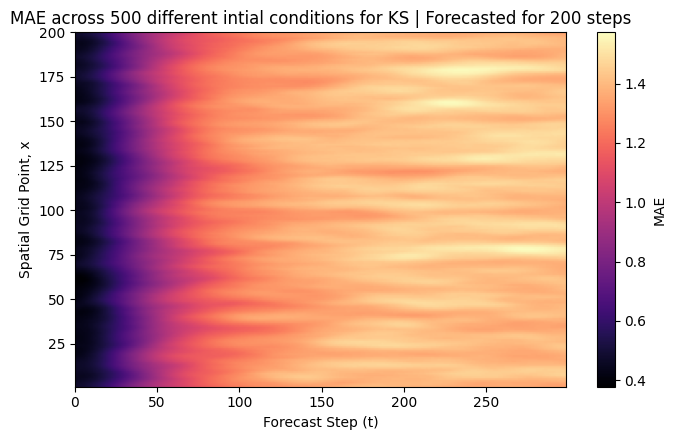

In [24]:
mae = mae_per_step.T   # shape: (100, 200)
plt.figure(figsize=(7, 4.5))
im = plt.imshow(mae,aspect="auto",origin="lower",cmap="magma",extent=[0, mae.shape[1]-1, 1, mae.shape[0]])
plt.xlabel("Forecast Step (t)")
plt.ylabel("Spatial Grid Point, x")
plt.title("MAE across 500 different intial conditions for KS | Forecasted for 200 steps")
cbar = plt.colorbar(im)
cbar.set_label("MAE")
plt.tight_layout()
plt.show()

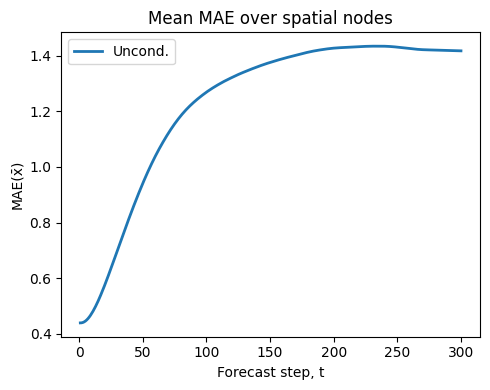

In [25]:
steps = np.arange(1, mae_per_step.shape[0] + 1)
mae_curve = mae_per_step.mean(axis=1)
plt.figure(figsize=(5, 4))
plt.plot(steps, mae_curve, label="Uncond.", linewidth=2)
plt.xlabel("Forecast step, t")
plt.ylabel("MAE(x̄)")
plt.title("Mean MAE over spatial nodes")
plt.legend()
plt.tight_layout()
plt.show()